# MTRN3100 Week 12 Part 2 - Obstacle Course Evaluation Output

Run `plan_route.py` before this notebook. It presents the two required outputs for the 5 x 5 obstacle-course evaluation:

1. the planned route over the obstacle-course image;
2. the robot action route as an `l`, `r`, `f` command string.

This notebook only reads the latest obstacle-course files. It does not run the planner or modify any project output.

In [13]:
import json
from pathlib import Path


def find_project_dir() -> Path:
    candidates = [Path.cwd(), Path.cwd() / "week12_part2"]
    for candidate in candidates:
        if (candidate / "plan_route.py").is_file():
            return candidate.resolve()
    raise FileNotFoundError(
        "Could not locate week12_part2. Open this notebook from the project workspace."
    )


PROJECT_DIR = find_project_dir()
OUTPUT_DIR = PROJECT_DIR / "output"
ROUTE_FILE = OUTPUT_DIR / "course_route.json"
PLANNING_IMAGE = OUTPUT_DIR / "course_planning_result.png"

for required_file in (ROUTE_FILE, PLANNING_IMAGE):
    if not required_file.is_file():
        raise FileNotFoundError(
            f"Missing {required_file}. Run plan_route.py first to generate "
            "the latest obstacle-course result."
        )

with ROUTE_FILE.open("r", encoding="utf-8") as stream:
    route = json.load(stream)

print(f"Loaded obstacle-course output from: {OUTPUT_DIR}")

Loaded obstacle-course output from: D:\3100\MTRN3100-T05\week12_part2\output


## 1. Planned Obstacle-Course Route

The image below is generated by `plan_route.py`. It shows the selected 5 x 5 obstacle area, detected cylinders, entrance, exit and collision-free planned route.

**Detected obstacles:** `2` &nbsp;&nbsp; **Planned path points:** `8`

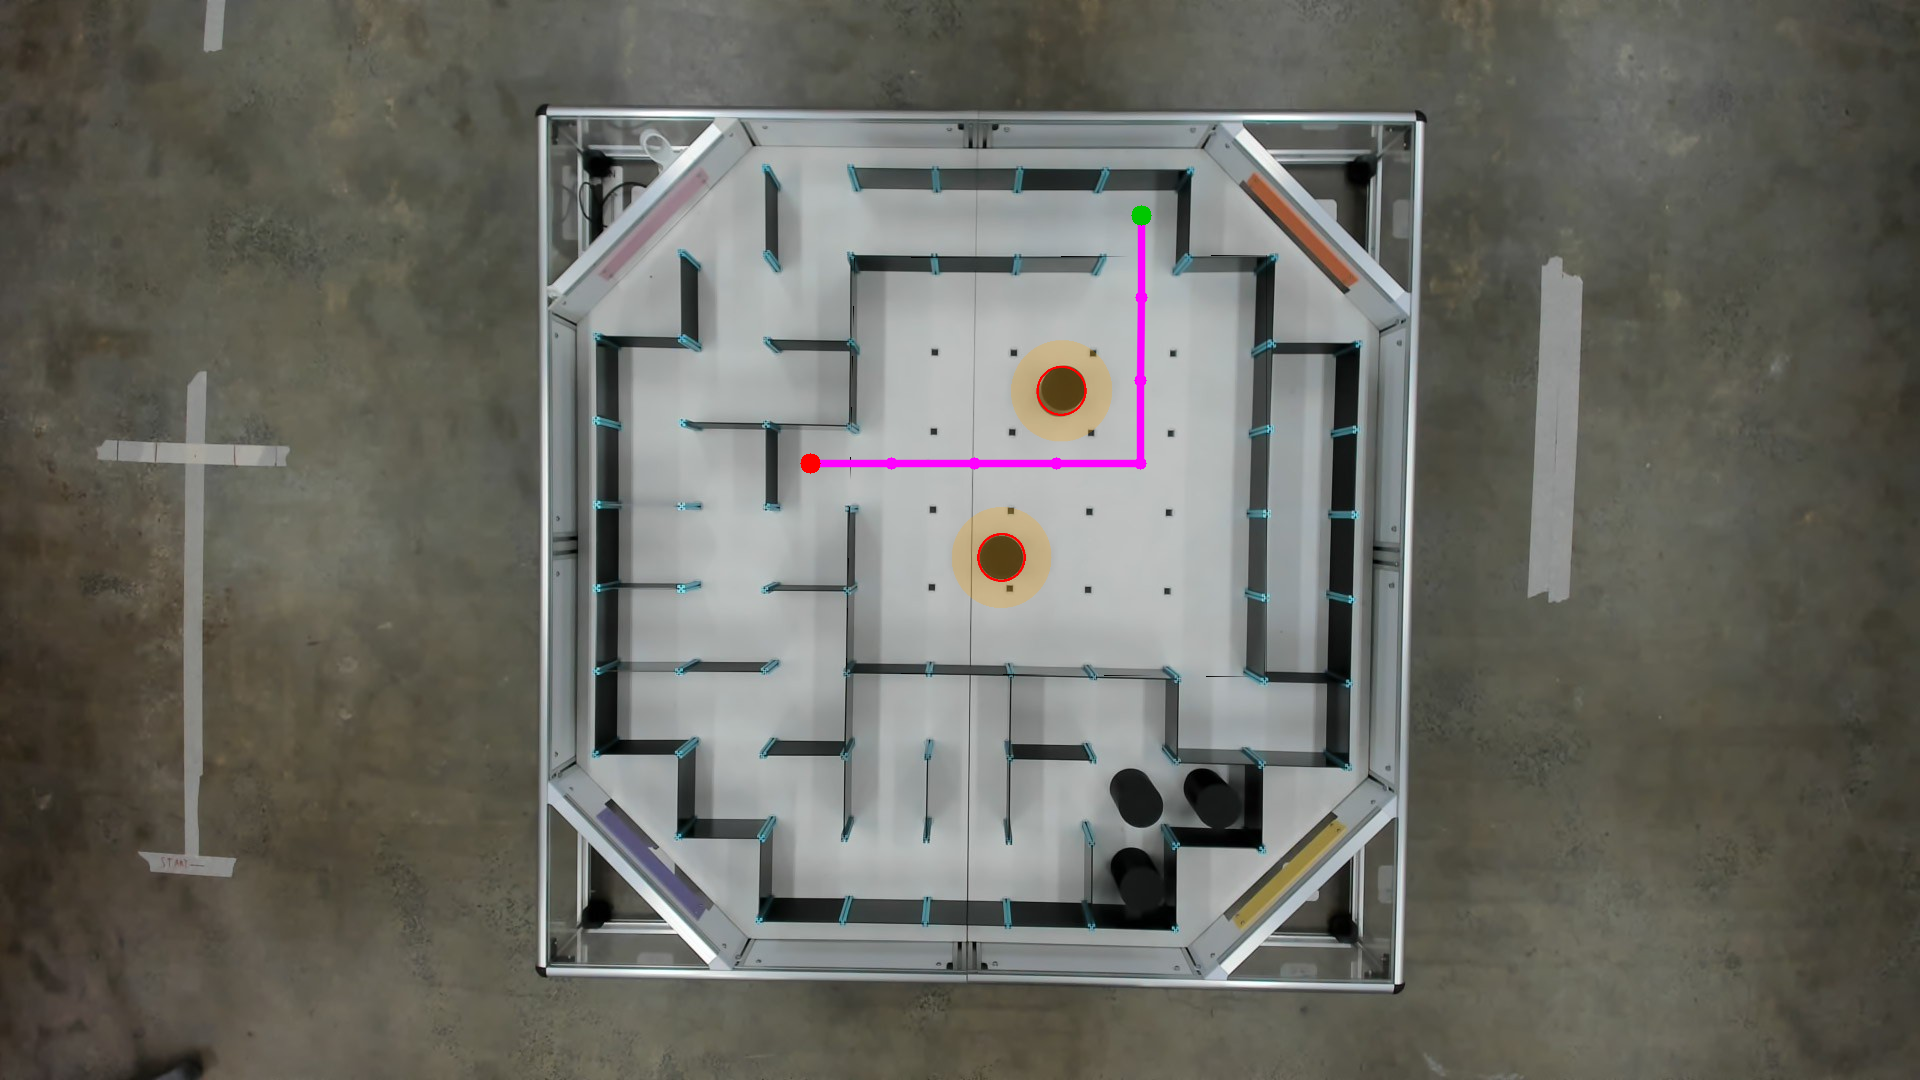

In [14]:
from IPython.display import Image, Markdown, display

obstacle_count = len(route.get("obstacles", []))
path_points = route.get("path_mm", [])

display(
    Markdown(
        f"**Detected obstacles:** `{obstacle_count}` &nbsp;&nbsp; "
        f"**Planned path points:** `{len(path_points)}`"
    )
)
display(Image(filename=str(PLANNING_IMAGE), width=1000))

## 2. Robot Action Route

Each character is one robot action:

- `f`: move forward;
- `l`: turn left;
- `r`: turn right.

The complete string below is the obstacle-course command sequence generated by `plan_route.py`.

In [15]:
course_commands = str(route.get("grid_commands", ""))
if not course_commands:
    raise ValueError("course_route.json does not contain grid_commands")

invalid_commands = set(course_commands) - set("lrf")
if invalid_commands:
    raise ValueError(f"Route contains invalid commands: {sorted(invalid_commands)}")

print(f"Command string: {course_commands}")

Command string: fffrffff
